# EDA — Fichiers de scraping EventZilla

Notebook dédié à la **description des données scrappées**, aux **méthodes de scraping**, aux **URLs sources** et au **chargement / aperçu** des CSV. Les scripts de génération (scrape_*.py) ne sont pas exécutés dans ce notebook ; les fichiers doivent être générés en amont par les scripts dans `DataProjet/Scrapping/`.

**Fichiers couverts :**
1. **Venues / Salles** → `venues_salles_tunisie_ranim.csv` (fichier de référence avec vrais contacts)
2. **Tendances événementielles** → `tendances_evenementielles_tunisie.csv`
3. **Benchmark prix marché** → `benchmark_prix_marche_tunisie.csv`
4. **Holidays (jours fériés)** → `external_holidays.csv` (généré par `scrape_holidays_tunisie.py` — urllib + regex, timeanddate.com ; voir **EDA_Scrapping_Holidays.ipynb** pour exécution)

**Référence KPIs** : Les indicateurs proposés pour chaque fichier scrappé sont alignés sur le **cahier des charges (CDC) EventZilla** et sur le document **Analyse_CDC_Data_Scrapping_KPIs** (KPIs opérationnels, qualité, business, produit, **contextuels**). Les KPIs « contextuels » sont ceux alimentés ou enrichis par le scrapping (jours fériés, benchmark prix, tendances, taille d’offre).

### Synthèse : Fichiers scrappés → KPIs CDC (référence)

| Fichier scrappé | Axe | KPIs CDC concernés (section 5.1 / 5.4 / 4.4) |
|------------------|-----|--------------------------------------------------|
| **venues_salles_tunisie_ranim.csv** | **Suggestions salles populaires** | Alimenter les suggestions des salles les plus populaires en Tunisie (par région, type d’événement, contact). |
| **tendances_evenementielles_tunisie.csv** | **Potentiel catégories à ajouter** | Analyser les potentiels de catégories d’événements à ajouter futurément à la plateforme. |
| **benchmark_prix_marche_tunisie.csv** | Prix | **Positionnement tarifaire** vs marché (5.4, 6) ; part réservations sous/au-dessus/alignées marché ; aide à l’offre prestataires. |
| **external_holidays.csv** | Calendrier | **Taux de réservation les jours fériés** ; **Panier moyen les jours fériés** (contextuels 5.1, 5.3) ; évolution taux de conversion par type de jour (5.4). |

---
## 1. Venues / Salles de fêtes — `venues_salles_tunisie_ranim.csv`
---

**Objectif métier** : Les données sont scrapées pour **alimenter les suggestions des salles les plus populaires en Tunisie** (affichage par région, type d’événement, avec contact pour faciliter la prise de rendez-vous). **Fichier de référence** : `venues_salles_tunisie_ranim.csv` — vrais contacts (téléphone, Instagram/Facebook de chaque lieu), régénéré par `generate_venues_salles_tunisie_ranim.py`. Aucune entrée fictive ; toutes les lignes ont un contact exploitable.

### 1.1 Description des données et des colonnes

| Colonne | Description |
|---------|-------------|
| **venue_name** | Nom du lieu (salle, club, espace événementiel). Hors doublons et lieux fictifs. |
| **region** | Zone / adresse affichée (ex. Gammarth, Sousse, Hammamet). |
| **gouvernorat** | Gouvernorat tunisien standardisé (parmi les 24). |
| **event_types** | Types d’événements proposés (ex. Wedding; Birthday; Private Party; Corporate Event). |
| **contact** | Téléphone, ou lien Instagram/Facebook, ou email (priorité : téléphone > réseaux sociaux > email). Les liens réseau social peuvent avoir été enrichis via l’EDA Venues (section 5) pour remplacer les liens tunis.events par les comptes réels des lieux. |

### 1.2 Méthode (fichier de référence vs scraping)

- **Fichier utilisé pour l'EDA** : `venues_salles_tunisie_ranim.csv` est généré par `generate_venues_salles_tunisie_ranim.py`  
- **Scraping** : `urllib.request.Request` + `urlopen` (stdlib Python).
- **Parsing** : **regex** (`re`) sur le HTML ; **sans BeautifulSoup**, **sans API dédiée**.
- **Pages listées** : pages liste par ville sur tunis.events → noms, régions, liens vers fiches détail.
- **Fiches détail** : une requête par lieu (URL `/fr/places/<slug>`) pour extraire téléphone, email, liens Instagram/Facebook.
- **Recherche web**  : recherche Google pour trouver comptes Instagram/Facebook des lieux sans réseau social dans la fiche.
- **Fichier utilisé** : ne contient que les lieux pour lesquels un **contact** (téléphone, réseau social ou email) est renseigné ; les lignes sans contact ont été éliminées. Les liens vers **instagram.com/tunis.events** (ou facebook tunis.events) ne sont **jamais** conservés comme contact (page agrégateur). Les entrées fictives « Lieu événementiel - [Gouvernorat] » sont **exclues** de l’export.

- **Enrichissement des contacts (réseaux sociaux)** : sur tunis.events, beaucoup de fiches renvoient le même lien Instagram (tunis.events) au lieu du compte propre à chaque lieu. Dans le notebook **EDA_Scrapping_Venues_Salles_Tunisie** (section 5), une étape permet de **rechercher les vrais comptes** Instagram/Facebook de chaque venue (recherche web) et de **remplacer** dans le CSV les contacts pointant vers tunis.events par l’URL du lieu lorsqu’elle est trouvée. Une étape **nettoyage** (section 5b) supprime du CSV les lignes « Lieu événementiel » et les lignes dont le contact est resté tunis.events. Exécuter ces étapes pour un fichier à jour.

### 1.3 URLs sources (concrètes)

| URL | Rôle |
|-----|------|
| https://tunis.events/fr/places | Liste des lieux (Tunis / Gammarth) |
| https://tunis.events/fr/places/sousse | Liste des lieux Sousse |
| https://tunis.events/fr/places/mahdia | Liste des lieux Mahdia |
| https://tunis.events/fr/places/hammamet | Liste des lieux Hammamet |
| https://tunis.events/fr/places/<slug> | Fiche détail d’un lieu (téléphone, email, réseaux sociaux) |

*(Recherche web éventuelle : Google pour compléter Instagram/Facebook.)*

### 1.4 Relations possibles avec les données EventZilla

- **Suggestions salles populaires** : les lieux scrapés alimentent le moteur de **suggestions** pour la sous-catégorie **Venue** (SERVICE + SUBCATEGORY) ; filtrage par `gouvernorat` / `region` et par `event_types` (Wedding, Birthday, Corporate Event, Private Party) pour afficher les salles les plus populaires selon la zone et le type d’événement.
- **PROVIDER** : rapprochement possible avec `PROVIDER.city` pour enrichir la base prestataires ou dédupliquer ; les venues scrapées peuvent servir de **catalogue externe** de salles à suggérer même si elles ne sont pas encore prestataires EventZilla.
- **EVENT** : croisement avec EVENT.type pour proposer des salles adaptées au type d’événement (mariage, anniversaire, etc.).

### 1.5 KPIs (alignés usage : suggestions des salles les plus populaires)

Les venues sont scrapées pour **alimenter les suggestions** de salles populaires. Les KPIs ci-dessous mesurent la qualité et la couverture de la base utilisée pour ces suggestions.

**Source de données** : `DataProjet/Scrapping/venues_salles_tunisie_ranim.csv` — colonnes : `venue_name`, `region`, `gouvernorat`, `event_types`, `contact`.

| KPI | Formule / Méthode | Usage |
|-----|------------------|-------|
| **Nombre de salles suggérables** | COUNT(venue_name) — hors doublons et lieux fictifs. | Taille du catalogue utilisable pour suggestions. |
| **Couverture géographique** | COUNT(DISTINCT gouvernorat) / 24. | % de gouvernorats couverts par au moins une salle. |
| **Part des salles joignables** | COUNT(contact NOT NULL) / COUNT(total venues) × 100. | Qualité : % de lieux avec contact valide (tél, email, réseaux sociaux). |
| **Répartition des salles par gouvernorat** | COUNT(venue_name) GROUP BY gouvernorat. | Identifier les régions « stars » (ex. Tunis, Sousse). |
| **Couverture par type d’événement** | Pour chaque type attendu (Wedding, Birthday, Corporate, Private Party) : compter les lignes où `event_types` contient ce type. | Vérifier la pertinence et la diversité des types d'événements. |

### 1.6 Chargement et aperçu

In [3]:
import os
import pandas as pd

# Emplacement CSV : CSV_scrapping/ (projet) ou DataProjet/Scrapping (fallback)
_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "EDA" else os.getcwd()
scratch_dir = os.path.join(_root, "CSV_scrapping")
if not os.path.exists(scratch_dir):
    scratch_dir = os.path.join(_root, "DataProjet", "Scrapping")
if not os.path.exists(scratch_dir):
    scratch_dir = os.path.join(os.getcwd(), "CSV_scrapping")
print("Dossier CSV scraping:", scratch_dir)

Dossier CSV scraping: c:\Users\ranim\Downloads\ValidationPI\ValidationPI\CSV_scrapping


In [4]:
import pandas as pd

path_venues = os.path.join(scratch_dir, "venues_salles_tunisie_ranim.csv")
if not os.path.exists(path_venues):
    path_venues = os.path.join(scratch_dir, "venues_salles_tunisie.csv")
if os.path.exists(path_venues):
    df_venues = pd.read_csv(path_venues, sep=";", encoding="utf-8-sig")
    print("Aperçu", os.path.basename(path_venues))
    display(df_venues.head(12))
    print("\nShape:", df_venues.shape)
    print("Colonnes:", list(df_venues.columns))
else:
    print("Fichier non trouvé. Générer avec generate_venues_salles_tunisie_ranim.py ou scrape_venues_salles_tunisie.py.")

Aperçu venues_salles_tunisie_ranim.csv


,venue_name,region,gouvernorat,event_types,contact
0,Cocoon,"Complexe Le Cap, Gammarth",Tunis,Wedding;Birthday;Private Party;Corporate Event,21974226
1,Molo,"Le Cap Gammarth, zone touristique",Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.instagram.com/molo.tunis/
2,Foll'Amour,Gammarth,Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.instagram.com/follamour_gammarth_o...
3,BSMNT The Club,"Gammarth, tunis",Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.facebook.com/BSMNTTheClub/
4,Habibi,Rooftop Hotel Al Hana,Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.instagram.com/habibidowntown_/?hl=en
5,Club Gingembre,The Cap Gammarth,Tunis,Wedding;Birthday;Private Party;Corporate Event,20762179
6,flō,Complexe Trinidad,Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.instagram.com/flo.tunis/
7,Red Kiss,"Le relais, Rte Express de Gamarth, Marsa 2046",Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.facebook.com/redkiss.tn/
8,El Firma,"58 Rue des Fruits - Choutrana III, La Soukra, ...",Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.instagram.com/elfirma.tunis/
9,Beatz,Gammarth,Tunis,Wedding;Birthday;Private Party;Corporate Event,https://www.instagram.com/beatz.club.gammarth/...



Shape: (33, 5)
Colonnes: ['venue_name', 'region', 'gouvernorat', 'event_types', 'contact']


### 1.7 Analyse exploratoire (qualité des données)

Vérification des **valeurs manquantes**, **doublons**, **valeurs aberrantes** et **distributions** pour le fichier Venues / Salles.

Valeurs manquantes par colonne :


,Valeurs manquantes,%
0,0,0


Aucune valeur manquante.

Doublons (lignes entièrement identiques) : 0
Lignes avec même (venue_name, region) : 0 (dont doublons stricts : 0)

Répartition par gouvernorat (vérification cohérence) :


gouvernorat
Tunis       19
Nabeul       6
Sousse       5
Mahdia       2
Monastir     1
Name: count, dtype: int64

Contacts vides ou invalides : 0


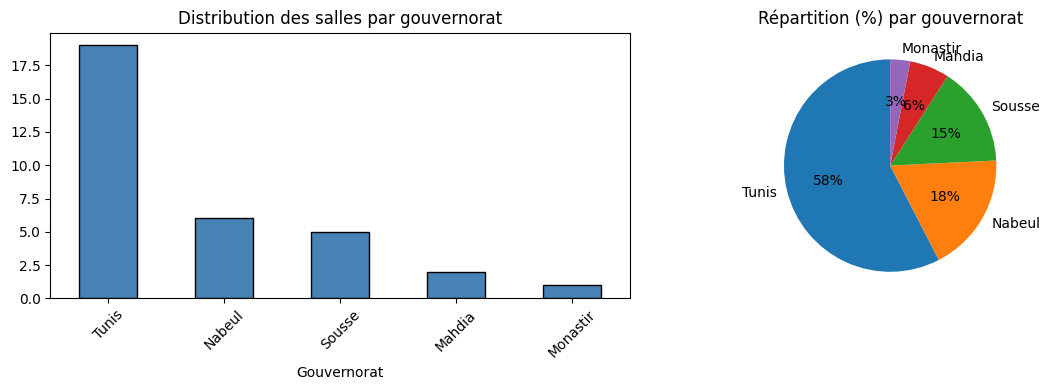

In [5]:
# Analyse exploratoire — Venues (salles)
if 'df_venues' in dir() and df_venues is not None:
    import matplotlib.pyplot as plt
    import numpy as np

    # --- Valeurs manquantes ---
    manquantes = df_venues.isna().sum()
    pct = (manquantes / len(df_venues) * 100).round(1)
    df_manq = pd.DataFrame({"Valeurs manquantes": manquantes, "%": pct})
    print("Valeurs manquantes par colonne :")
    display(df_manq[df_manq["Valeurs manquantes"] > 0] if manquantes.sum() > 0 else pd.DataFrame({"Valeurs manquantes": [0], "%": [0]}))
    if manquantes.sum() == 0:
        print("Aucune valeur manquante.")

    # --- Doublons ---
    dup_all = df_venues.duplicated().sum()
    dup_venue = df_venues.duplicated(subset=["venue_name", "region"], keep=False)
    print(f"\nDoublons (lignes entièrement identiques) : {dup_all}")
    print(f"Lignes avec même (venue_name, region) : {dup_venue.sum()} (dont doublons stricts : {df_venues.duplicated(subset=['venue_name','region']).sum()})")
    if dup_venue.sum() > 0:
        display(df_venues[dup_venue].sort_values(["venue_name", "region"]))

    # --- Valeurs aberrantes / cohérence ---
    # Gouvernorats attendus (24 en Tunisie) — repérage d'éventuelles typos
    gouv_connus = df_venues["gouvernorat"].value_counts()
    print("\nRépartition par gouvernorat (vérification cohérence) :")
    display(gouv_connus)
    # Contacts vides ou invalides (chaîne vide après strip)
    contact_vide = df_venues["contact"].astype(str).str.strip().isin(["", "nan", "None"])
    print(f"Contacts vides ou invalides : {contact_vide.sum()}")

    # --- Schémas de distribution ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df_venues["gouvernorat"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
    axes[0].set_title("Distribution des salles par gouvernorat")
    axes[0].set_xlabel("Gouvernorat")
    axes[0].tick_params(axis="x", rotation=45)
    df_venues["gouvernorat"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.0f%%", startangle=90)
    axes[1].set_title("Répartition (%) par gouvernorat")
    plt.tight_layout()
    plt.show()
else:
    print("Charger d'abord df_venues (cellule section 1.6).")

---
## 2. Tendances événementielles — `tendances_evenementielles_tunisie.csv`
---

**Objectif métier** : Les données sont scrapées pour **analyser les potentiels de catégories d’événements à ajouter futurément** à la plateforme (au-delà de Wedding, Birthday, Corporate Event, Private Party).

### 2.1 Description des données et des colonnes

| Colonne | Description |
|---------|-------------|
| **category_name** | Libellé de la catégorie d’événements (ex. Arts et Culture, Sport et Fitness). |
| **category_slug** | Identifiant URL (ex. evenements-arts-et-culture-tunisie). |
| **source** | Nom de la source (evenement.tn). |
| **source_url** | URL concrète de la page catégorie sur evenement.tn. |
| **event_count_observed** | Nombre approximatif d’événements/liens observés sur la page catégorie (indicateur de tendance). |

### 2.2 Méthode de scraping

- **HTTP** : `urllib.request.Request` + `urlopen` (stdlib).
- **Parsing** : **regex** sur le HTML ; **sans BeautifulSoup**, **sans API**.
- **Page d’entrée** : page « Événements » evenement.tn → extraction des liens vers les catégories (evenements-XXX-tunisie).
- **Par catégorie** : une requête par URL catégorie pour compter les liens/événements (event_count_observed).

### 2.3 URLs sources (concrètes)

| URL | Rôle |
|-----|------|
| https://www.evenement.tn/evenements | Page liste des catégories d’événements |
| https://www.evenement.tn/evenements-arts-et-culture-tunisie/ | Exemple catégorie Arts et Culture |
| https://www.evenement.tn/evenements-education-et-formation-tunisie/ | Éducation et Formation |
| https://www.evenement.tn/evenements-technologie-et-innovation-tunisie/ | Technologie et Innovation |
| https://www.evenement.tn/evenements-sante-et-bien-etre-tunisie/ | Santé et Bien-être |
| https://www.evenement.tn/evenements-sport-et-fitness-tunisie/ | Sport et Fitness |
| https://www.evenement.tn/evenements-voyage-tourisme-et-loisirs-tunisie/ | Voyage Tourisme et Loisirs |
| https://www.evenement.tn/evenements-affaires-entrepreneuriat-et-commerce-tunisie/ | Affaires Entrepreneuriat et Commerce |
| https://www.evenement.tn/evenements-caritatif-et-volontariat-tunisie/ | Caritatif et Volontariat |
| https://www.evenement.tn/evenements-gastronomie-et-boissons-tunisie/ | Gastronomie et Boissons |
| https://www.evenement.tn/evenements-mode-et-beaute-tunisie/ | Mode et Beauté |
| https://www.evenement.tn/evenements-famille-et-enfants-tunisie/ | Famille et Enfants |
| https://www.evenement.tn/evenements-geek-jeux-et-pop-culture-tunisie/ | Geek Jeux et Pop Culture |

### 2.4 Relations possibles avec les données EventZilla

- **CATEGORY / EVENT** : comparer les **catégories existantes** EventZilla (Wedding, Birthday, Corporate Event, Private Party) aux catégories evenement.tn pour identifier les **nouvelles catégories** à ajouter (Arts et Culture, Sport et Fitness, Gastronomie, etc.).
- **Priorisation** : `event_count_observed` par catégorie sert d’indicateur de **potentiel** pour décider quelles catégories intégrer en premier dans le catalogue et les suggestions.

### 2.5 KPIs (alignés usage : potentiel des catégories à ajouter)

Les tendances sont scrapées pour **identifier les catégories d’événements à fort potentiel**, à ajouter futurément à la plateforme.

**Sources de données** : `DataProjet/Scrapping/tendances_evenementielles_tunisie.csv` (colonnes : `category_name`, `category_slug`, `event_count_observed`) ; `DataProjet/Datacsv/CATEGORY.csv` (colonnes : `id_category`, `name` — types actuels : Wedding, Corporate, Birthday, Private Party).

| KPI | Formule / Méthode | Usage |
|-----|------------------|-------|
| **Potentiel par catégorie** | `event_count_observed` par catégorie. | Identifier les catégories les plus demandées. |
| **Part de chaque catégorie** | (event_count_observed / SUM(event_count_observed)) × 100. | Pondération de chaque catégorie dans le marché global. |
| **Catégories nouvelles vs couvertes** | SET_DIFF(catégories marché, catégories EventZilla actuelles). | Roadmap produit : distinguer nouvelles catégories à intégrer. |
| **Top N catégories à ajouter** | TOP N(event_count_observed) hors catégories déjà couvertes. | Prioriser les ajouts pour maximiser attractivité. |

### 2.6 Chargement et aperçu

In [6]:
path_tendances = os.path.join(scratch_dir, "tendances_evenementielles_tunisie.csv")
if os.path.exists(path_tendances):
    df_tendances = pd.read_csv(path_tendances, sep=";", encoding="utf-8-sig")
    print("Aperçu tendances_evenementielles_tunisie.csv")
    display(df_tendances)
    print("\nShape:", df_tendances.shape)
else:
    print("Fichier non trouvé. Générer avec DataProjet/Scrapping/scrape_tendances_evenementielles_tunisie.py.")

Aperçu tendances_evenementielles_tunisie.csv


,category_name,category_slug,source,source_url,event_count_observed
0,Arts et Culture,evenements-arts-et-culture-tunisie,evenement.tn,https://www.evenement.tn/evenements-arts-et-cu...,65
1,Éducation et Formation,evenements-education-et-formation-tunisie,evenement.tn,https://www.evenement.tn/evenements-education-...,65
2,Technologie et Innovation,evenements-technologie-et-innovation-tunisie,evenement.tn,https://www.evenement.tn/evenements-technologi...,65
3,Santé et Bien-être,evenements-sante-et-bien-etre-tunisie,evenement.tn,https://www.evenement.tn/evenements-sante-et-b...,65
4,Sport et Fitness,evenements-sport-et-fitness-tunisie,evenement.tn,https://www.evenement.tn/evenements-sport-et-f...,65
5,Voyage Tourisme et Loisirs,evenements-voyage-tourisme-et-loisirs-tunisie,evenement.tn,https://www.evenement.tn/evenements-voyage-tou...,148
6,Affaires Entrepreneuriat et Commerce,evenements-affaires-entrepreneuriat-et-commerc...,evenement.tn,https://www.evenement.tn/evenements-affaires-e...,106
7,Caritatif et Volontariat,evenements-caritatif-et-volontariat-tunisie,evenement.tn,https://www.evenement.tn/evenements-caritatif-...,65
8,Gastronomie et Boissons,evenements-gastronomie-et-boissons-tunisie,evenement.tn,https://www.evenement.tn/evenements-gastronomi...,85
9,Mode et Beauté,evenements-mode-et-beaute-tunisie,evenement.tn,https://www.evenement.tn/evenements-mode-et-be...,65



Shape: (12, 5)


### 2.7 Analyse exploratoire (qualité des données)

Valeurs manquantes, doublons, valeurs aberrantes et distributions pour **tendances événementielles**.

Valeurs manquantes par colonne :


,Valeurs manquantes,%
category_name,0,0.0
category_slug,0,0.0
source,0,0.0
source_url,0,0.0
event_count_observed,0,0.0


Aucune valeur manquante.

Doublons (lignes entièrement identiques) : 0
Lignes avec même category_name : 0 | même category_slug : 0

Valeurs aberrantes event_count_observed : négatives = 0, manquantes = 0
Min = 65, Max = 148, Moyenne = 77.0


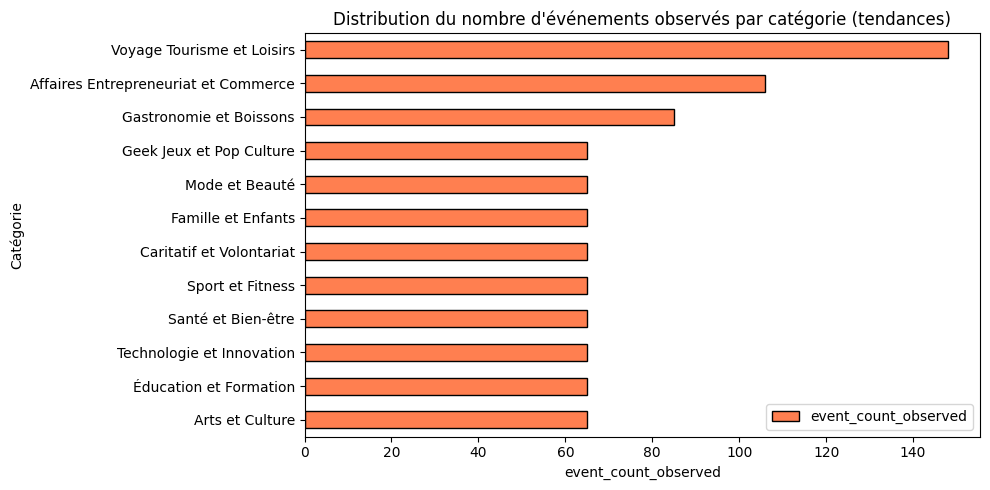

In [7]:
# Analyse exploratoire — Tendances événementielles
if 'df_tendances' in dir() and df_tendances is not None:
    import matplotlib.pyplot as plt

    # --- Valeurs manquantes ---
    manquantes = df_tendances.isna().sum()
    pct = (manquantes / len(df_tendances) * 100).round(1)
    df_manq = pd.DataFrame({"Valeurs manquantes": manquantes, "%": pct})
    print("Valeurs manquantes par colonne :")
    display(df_manq)
    if manquantes.sum() == 0:
        print("Aucune valeur manquante.")

    # --- Doublons ---
    dup_all = df_tendances.duplicated().sum()
    dup_cat = df_tendances.duplicated(subset=["category_name"], keep=False).sum()
    dup_slug = df_tendances.duplicated(subset=["category_slug"], keep=False).sum()
    print(f"\nDoublons (lignes entièrement identiques) : {dup_all}")
    print(f"Lignes avec même category_name : {dup_cat} | même category_slug : {dup_slug}")

    # --- Valeurs aberrantes ---
    col_count = "event_count_observed"
    if col_count in df_tendances.columns:
        neg = (df_tendances[col_count] < 0).sum()
        nul = (df_tendances[col_count].isna()).sum()
        print(f"\nValeurs aberrantes {col_count} : négatives = {neg}, manquantes = {nul}")
        print(f"Min = {df_tendances[col_count].min()}, Max = {df_tendances[col_count].max()}, Moyenne = {df_tendances[col_count].mean():.1f}")

    # --- Schémas de distribution ---
    fig, ax = plt.subplots(figsize=(10, 5))
    df_tendances.sort_values("event_count_observed", ascending=True).plot(
        x="category_name", y="event_count_observed", kind="barh", ax=ax, color="coral", edgecolor="black"
    )
    ax.set_title("Distribution du nombre d'événements observés par catégorie (tendances)")
    ax.set_xlabel("event_count_observed")
    ax.set_ylabel("Catégorie")
    plt.tight_layout()
    plt.show()
else:
    print("Charger d'abord df_tendances (cellule section 2.6).")

---
## 3. Benchmark prix marché — `benchmark_prix_marche_tunisie.csv`
---

### 3.1 Description des données et des colonnes

| Colonne | Description |
|---------|-------------|
| **Subcategory** | Sous-catégorie de service : Venue (Salle), Catering (Traiteur), Entertainment, Decoration. |
| **Saisonnalité** | Haute Saison, Basse Saison, Intermédiaire, Ramadan. |
| **Période indicative** | Période calendaire (ex. Juin - Septembre, Novembre - Février). |
| **Average Price (Marché TN)** | Prix moyen observé sur le marché tunisien (DT ou DT/pers.), issu du scraping + articles. |

### 3.2 Méthode de scraping

- **HTTP** : `urllib.request.Request` + `urlopen` (stdlib).
- **Parsing** : **regex** (et **lxml** en option si installé) sur le HTML pour extraire montants en DT/TND.
- **Scraping** : requêtes sur les URLs listées ci-dessous pour extraire des prix réels (salles, traiteur, décoration).
- **Données complémentaires** : saisie à partir d’articles (Belvédère, OTOC, Iftar, etc.) — pas de scraping sur les URLs d’articles.
- **Agrégation** : prix agrégés par (Subcategory, Saisonnalité) puis export en tableau Subcategory × Saisonnalité.

### 3.3 URLs sources (concrètes)

**URLs effectivement scrapées (HTTP) :**

| URL | Données extraites |
|-----|-------------------|
| https://www.elysee-du-lac.com/tarifs | Tarifs salles (DT) |
| https://resaprivee.com/fr/29-traiteur | Tarifs traiteur (TND/pers., forfaits) |
| https://www.1001-nights-palace.com/meet | Forfait mariage (TND) |
| https://tayara.tn/listing/c/pour-la-maison-et-jardin/meubles-et-d%C3%A9coration/?page=1 | Prix décoration (DT) |

**Articles (données saisies manuellement, pas de scraping) :**

| URL | Usage |
|-----|--------|
| https://news-tunisia.tunisienumerique.com/... (Belvédère) | Tarifs salle Belvédère |
| https://www.webdo.tn/... (mariage, OTOC) | Salle des fêtes, orchestre, décoration |
| https://tunisie.co/article/... (Iftars) | Prix Iftar / traiteur Ramadan |
| https://www.mariageatoutprix.com/... (reception/music) | Entertainment (troupe, musique) |

### 3.4 Relations possibles avec les données EventZilla

- **SERVICE + SUBCATEGORY** : jointure sur la sous-catégorie — aligner `Subcategory` du benchmark (Venue (Salle), Catering (Traiteur), Entertainment, Decoration) avec `SUBCATEGORY.name` (Venue, Catering, etc.) dans EventZilla.
- **RESERVATION** : croiser `final_price` des réservations avec le prix moyen marché (par Subcategory × Saisonnalité) pour calculer les écarts et le positionnement tarifaire.

### 3.5 KPIs (alignés CDC EventZilla — axe Benchmark prix)

Rappel CDC : 5.4 « Benchmark prix prestataires » ; KPI **positionnement tarifaire** (section 6).

Les KPIs ci‑dessous utilisent un **benchmark par sous-catégorie uniquement** (moyenne des 4 saisonnalités du fichier benchmark), sans mapping date → saisonnalité : une seule valeur de référence par sous-catégorie, plus simple à calculer et à interpréter.

**Sources de données** : `DataProjet/Scrapping/benchmark_prix_marche_tunisie.csv` (colonnes : `Subcategory`, `Average Price (Marché TN)` — à parser en numérique) ; `DataProjet/Datacsv/RESERVATION.csv` ; `DataProjet/Datacsv/SERVICE.csv` ; `DataProjet/Datacsv/SUBCATEGORY.csv`. **Mapping sous-catégorie** : SUBCATEGORY.name ↔ Subcategory du CSV (Venue (Salle), Catering (Traiteur), Entertainment, Decoration) — à normaliser avant jointure.

**benchmark_price** = MOYENNE(« Average Price (Marché TN) ») sur les 4 lignes de la sous-catégorie (fichier benchmark — 4 saisonnalités). Sous-catégorie = celle de la réservation (RESERVATION → SERVICE → SUBCATEGORY). *Total* = réservations confirmées avec benchmark.

| KPI | Formule (complète et concrète) | Objectif / Logique | Source(s) / Note |
|-----|-------------------------------|-------------------|------------------|
| **Part réservations sous marché** | **(COUNT(réservations où final_price &lt; 0,85 × benchmark_price) / COUNT(total))** × 100. *Total* = réservations confirmées avec benchmark (même dénominateur pour les 3 parts). | Part des réservations vendues **moins cher** que le marché (≥15 % en dessous). Offres attractives ; risque marges faibles. | RESERVATION, SERVICE, SUBCATEGORY, benchmark_prix_marche_tunisie.csv (benchmark = moyenne par sous-catégorie). |
| **Part réservations alignées marché** | **(COUNT(réservations où 0,85 × benchmark_price ≤ final_price ≤ 1,15 × benchmark_price) / COUNT(total))** × 100. | Part des réservations dont le prix est **proche du marché** (±15 %). Zone cible, compétitif et perçu comme juste. | RESERVATION, SERVICE, SUBCATEGORY, benchmark_prix_marche_tunisie.csv (benchmark = moyenne par sous-catégorie). |
| **Part réservations au-dessus marché** | **(COUNT(réservations où final_price &gt; 1,15 × benchmark_price) / COUNT(total))** × 100. | Part des réservations vendues **plus cher** que le marché (≥15 % au-dessus). Position premium ; risque concurrence. | RESERVATION, SERVICE, SUBCATEGORY, benchmark_prix_marche_tunisie.csv (benchmark = moyenne par sous-catégorie). |
| **Écart médian prix EventZilla vs benchmark (par sous-catégorie)** | Même benchmark par sous-catégorie. Écart par réservation = (final_price − benchmark_price) / benchmark_price ; KPI = **MEDIANE** de ces écarts (par sous-catégorie ou global). | Résumé robuste du positionnement (moins sensible aux valeurs extrêmes que la moyenne). | RESERVATION, SERVICE, SUBCATEGORY, benchmark_prix_marche_tunisie.csv (benchmark = moyenne par sous-catégorie). |

### 3.6 Chargement et aperçu

In [8]:
# --- KPIs Benchmark (section 3.5) : préparation des données ---
# Exécuter après chargement de df_bench (cellule précédente).

if 'df_bench' in dir() and df_bench is not None and len(df_bench) > 0:
    import re

    # Parser "Average Price (Marché TN)" en numérique (retirer " DT", " DT / pers.", espaces)
    def parse_price(s):
        if pd.isna(s): return None
        s = str(s).replace(" ", "").replace("\u202f", "")
        m = re.search(r"([\d,.]+)", s)
        return float(m.group(1).replace(",", ".")) if m else None

    df_bench = df_bench.copy()
    col_price = "Average Price (Marché TN)"
    df_bench["price_numeric"] = df_bench[col_price].apply(parse_price)

    # Benchmark par sous-catégorie (moyenne / min / max sur les 4 saisonnalités) — pour les KPIs 3.5
    benchmark_par_subcategory = df_bench.groupby("Subcategory")["price_numeric"].agg(["mean", "min", "max"]).round(2)
    benchmark_par_subcategory.columns = ["benchmark_moyen", "benchmark_min", "benchmark_max"]
    print("Benchmark par sous-catégorie (moyenne / min / max sur toutes saisonnalités) — pour KPIs 3.5 :")
    display(benchmark_par_subcategory)
else:
    print("Charger d'abord df_bench (cellule précédente).")

Charger d'abord df_bench (cellule précédente).


### 3.7 Analyse exploratoire (qualité des données)

Valeurs manquantes, doublons, valeurs aberrantes (prix) et distributions pour le **benchmark prix marché**.

In [9]:
# Analyse exploratoire — Benchmark prix marché
if 'df_bench' in dir() and df_bench is not None:
    import re
    import matplotlib.pyplot as plt

    # Parser le prix pour les analyses
    def _parse_price(s):
        if pd.isna(s): return None
        s = str(s).replace(" ", "").replace("\u202f", "")
        m = re.search(r"([\d,.]+)", s)
        return float(m.group(1).replace(",", ".")) if m else None

    col_price = "Average Price (Marché TN)"
    df_bench_eda = df_bench.copy()
    df_bench_eda["price_numeric"] = df_bench_eda[col_price].apply(_parse_price)

    # --- Valeurs manquantes ---
    manquantes = df_bench_eda.isna().sum()
    pct = (manquantes / len(df_bench_eda) * 100).round(1)
    df_manq = pd.DataFrame({"Valeurs manquantes": manquantes, "%": pct})
    print("Valeurs manquantes par colonne :")
    display(df_manq)
    print(f"Prix non parsables (price_numeric NaN) : {df_bench_eda['price_numeric'].isna().sum()}")

    # --- Doublons ---
    dup_all = df_bench_eda.duplicated().sum()
    dup_key = df_bench_eda.duplicated(subset=["Subcategory", "Saisonnalité"], keep=False).sum()
    print(f"\nDoublons (lignes entièrement identiques) : {dup_all}")
    print(f"Lignes avec même (Subcategory, Saisonnalité) : {dup_key}")

    # --- Valeurs aberrantes (prix) ---
    prix = df_bench_eda["price_numeric"].dropna()
    aberrant_neg = (prix <= 0).sum()
    print(f"\nPrix aberrant (≤ 0) : {aberrant_neg}")
    print(f"Prix : min = {prix.min()}, max = {prix.max()}, moyenne = {prix.mean():.2f}")

    # --- Schémas de distribution ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df_bench_eda.groupby("Subcategory")["price_numeric"].mean().plot(kind="bar", ax=axes[0], color="teal", edgecolor="black")
    axes[0].set_title("Prix moyen (benchmark) par sous-catégorie")
    axes[0].set_xlabel("Subcategory")
    axes[0].tick_params(axis="x", rotation=45)
    df_bench_eda.groupby("Saisonnalité")["price_numeric"].mean().plot(kind="bar", ax=axes[1], color="orange", edgecolor="black")
    axes[1].set_title("Prix moyen par saisonnalité")
    axes[1].set_xlabel("Saisonnalité")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Charger d'abord df_bench (cellule section 3.6).")

Charger d'abord df_bench (cellule section 3.6).


In [10]:
path_bench = os.path.join(scratch_dir, "benchmark_prix_marche_tunisie.csv")
if not os.path.exists(path_bench):
    path_bench = os.path.join(scratch_dir, "benchmark_prix_marche_tunisie_latest.csv")
if os.path.exists(path_bench):
    df_bench = pd.read_csv(path_bench, sep=";", encoding="utf-8-sig")
    print("Aperçu benchmark_prix_marche_tunisie.csv")
    display(df_bench)
    print("\nShape:", df_bench.shape)
else:
    print("Fichier non trouvé. Générer avec DataProjet/Scrapping/scrape_benchmark_prix_marche.py.")

Aperçu benchmark_prix_marche_tunisie.csv


,Subcategory,Saisonnalité,Période indicative,Average Price (Marché TN)
0,Venue (Salle),Haute Saison,Juin - Septembre,2 500 DT
1,Venue (Salle),Basse Saison,Novembre - Février,1 500 DT
2,Venue (Salle),Intermédiaire,Mars-Mai / Octobre,4 750 DT
3,Venue (Salle),Ramadan,Variable,2 500 DT
4,Catering (Traiteur),Haute Saison,Juin - Septembre,95 DT / pers.
5,Catering (Traiteur),Basse Saison,Novembre - Février,65 DT / pers.
6,Catering (Traiteur),Intermédiaire,Mars-Mai / Octobre,88 DT / pers.
7,Catering (Traiteur),Ramadan,Variable,55 DT / pers.
8,Entertainment,Haute Saison,Juin - Septembre,8 000 DT
9,Entertainment,Basse Saison,Novembre - Février,4 000 DT



Shape: (16, 4)


---
## 4. Holidays (Jours fériés) — `external_holidays.csv`
---

**Objectif métier** : Alimenter les **KPIs contextuels** (taux de réservation les jours fériés, panier moyen jours fériés, évolution du taux de conversion par type de jour — CDC 5.1, 5.3, 5.4). Les données sont **réelles** (calendrier officiel Tunisie). Le notebook **EDA_Scrapping_Holidays.ipynb** permet d'exécuter le script de génération et d'explorer les données ; ce fichier en décrit la source, la méthode et l'usage.

### 4.1 Description des données et des colonnes

| Colonne | Description |
|---------|-------------|
| **date** | Date du jour férié (format DD/MM/YYYY). |
| **local_name** | Nom du jour férié en arabe (ex. عيد الاستقلال). |
| **name** | Nom du jour férié en anglais/français (ex. Independence Day, New Year's Day). |
| **country_code** | Code pays (TN = Tunisie). |
| **is_national** | VRAI = jour férié national, FAUX = observance ou autre. |
| **types** | Type : Public, Observance, Season. |
| **is_holiday** | 1 = jour férié. |
| **day_of_week** | Jour de la semaine. |
| **is_weekend** | 1 = samedi ou dimanche, 0 = jour ouvré. |

### 4.2 Méthode de scraping

- **Aucune API** : les données sont extraites depuis le HTML des pages web.
- **Aucun BeautifulSoup** : parsing par **regex** (`re`) sur le code HTML récupéré.
- **Bibliothèque utilisée :** `urllib.request` (stdlib Python) pour les requêtes HTTP.
- **Principe :** pour chaque année (ex. 2022–2026), requête GET sur l'URL source ; extraction des lignes du tableau (date, jour de la semaine, nom du jour férié, type) via expressions régulières ; conversion des dates au format DD/MM/YYYY ; calcul de `day_of_week` et `is_weekend`.
- **Fallback :** si la page ne renvoie pas de tableau exploitable, le script utilise la liste des **8 jours fériés nationaux fixes** tunisiens (dates officielles) pour générer un CSV valide (données réelles, non fictives).

### 4.3 URLs sources

**Source principale :** [timeanddate.com – Jours fériés Tunisie](https://www.timeanddate.com/holidays/tunisia/)

| URL | Rôle |
|-----|------|
| https://www.timeanddate.com/holidays/tunisia/2022 | Jours fériés Tunisie 2022 |
| https://www.timeanddate.com/holidays/tunisia/2023 | Jours fériés Tunisie 2023 |
| https://www.timeanddate.com/holidays/tunisia/2024 | Jours fériés Tunisie 2024 |
| https://www.timeanddate.com/holidays/tunisia/2025 | Jours fériés Tunisie 2025 |
| https://www.timeanddate.com/holidays/tunisia/2026 | Jours fériés Tunisie 2026 |

### 4.4 Script de génération

Le fichier **`DataProjet/Scrapping/scrape_holidays_tunisie.py`** contient tout le code de scraping. Exécution en ligne de commande : `python scrape_holidays_tunisie.py`, ou depuis le notebook **EDA_Scrapping_Holidays.ipynb** (cellule dédiée). Aucune exécution dans ce notebook ; chargement et usage du CSV uniquement.

### 4.5 Relations possibles avec les données EventZilla

- **EVENT ↔ external_holidays** : jointure sur la date de l’événement (`EVENT.event_date` ↔ `external_holidays.date`) pour identifier les événements organisés les jours fériés nationaux.
- **RESERVATION ↔ external_holidays** : jointure sur la date de réservation (`RESERVATION.reservation_date` ↔ `external_holidays.date`) pour calculer le taux de réservation les jours fériés et comparer le comportement vs jours ouvrés.

### 4.6 KPIs (alignés CDC EventZilla — axe Holidays)

Rappel CDC : **KPIs contextuels** (5.1, 5.3) — Taux de réservation les jours fériés ; Panier moyen les jours fériés ; 5.4 évolution taux de conversion par type de jour.

**Sources de données** : `DataProjet/Scrapping/external_holidays.csv` (colonnes : `date` format DD/MM/YYYY, `is_national`, `is_weekend`) ; `DataProjet/Datacsv/RESERVATION.csv` (`reservation_date`, `final_price`, `status`) ; `DataProjet/Datacsv/EVENT.csv` (`event_date` — optionnel pour analyser les événements en jour férié) ; `DataProjet/Datacsv/VISITORS.csv` (`date`, `visitors`, `reservations`). *Attention* : normaliser les formats de date (DD/MM/YYYY vs YYYY-MM-DD) pour les jointures.

| KPI | Formule de calcul | Source(s) de données |
|-----|-------------------|----------------------|
| **Taux de réservation les jours fériés** | (Nombre de réservations dont la date normalisée de `reservation_date` appartient à l’ensemble des `date` de **external_holidays** où is_national = VRAI) / (Nombre total de réservations) × 100. | **external_holidays.csv** (`date`, `is_national`) ; **RESERVATION.csv** (`reservation_date`). |
| **Panier moyen jours fériés vs jours ouvrés** | Panier férié = Moyenne(`final_price`) pour les réservations dont reservation_date ∈ dates des jours fériés. Panier ouvrés = Moyenne(`final_price`) pour les autres. Comparer les deux moyennes. | **external_holidays.csv** (`date`) ; **RESERVATION.csv** (`reservation_date`, `final_price`, éventuellement `status`=confirmed). |
| **Évolution du taux de conversion par type de jour** | Par type de jour (férié / week-end / ouvré) : Taux = (Nombre de réservations sur les dates de ce type) / (Somme des `visitors` sur ces dates) × 100. Comparer les taux entre types. | **external_holidays.csv** (`date`, `is_weekend`) ; **RESERVATION.csv** (`reservation_date`) ; **VISITORS.csv** (`date`, `visitors`, `reservations`). |

### 4.7 Chargement du fichier (lecture seule)

Aperçu du CSV. Pour régénérer les données : exécuter `DataProjet/Scrapping/scrape_holidays_tunisie.py` ou la cellule de scraping dans **EDA_Scrapping_Holidays.ipynb**.


In [11]:
path_holidays = os.path.join(scratch_dir, "external_holidays.csv")
if os.path.exists(path_holidays):
    df_holidays = pd.read_csv(path_holidays, sep=";", encoding="utf-8-sig")
    print("Aperçu external_holidays.csv (lecture seule, pas de génération)")
    display(df_holidays.head(12))
    print("\nShape:", df_holidays.shape)
else:
    print("Fichier non trouvé:", path_holidays)

Aperçu external_holidays.csv (lecture seule, pas de génération)


,date,local_name,name,country_code,is_national,types,is_holiday,day_of_week,is_weekend
0,01/01/2022,رأس السنة الميلادية,New Year's Day,TN,VRAI,Public,1,Saturday,1
1,01/01/2023,رأس السنة الميلادية,New Year's Day,TN,VRAI,Public,1,Sunday,1
2,01/01/2024,رأس السنة الميلادية,New Year's Day,TN,VRAI,Public,1,Monday,0
3,01/01/2025,رأس السنة الميلادية,New Year's Day,TN,VRAI,Public,1,Wednesday,0
4,01/01/2026,رأس السنة الميلادية,New Year's Day,TN,VRAI,Public,1,Thursday,0
5,01/05/2022,عيد الشغل,Labour Day,TN,VRAI,Public,1,Sunday,1
6,01/05/2023,عيد الشغل,Labour Day,TN,VRAI,Public,1,Monday,0
7,01/05/2024,عيد الشغل,Labour Day,TN,VRAI,Public,1,Wednesday,0
8,01/05/2025,عيد الشغل,Labour Day,TN,VRAI,Public,1,Thursday,0
9,01/05/2026,عيد الشغل,Labour Day,TN,VRAI,Public,1,Friday,0



Shape: (40, 9)


---
## 5. Synthèse — Fichiers de scraping
---

| Fichier CSV | Script Python | Méthode | Source principale |
|-------------|----------------|---------|-------------------|
| venues_salles_tunisie_ranim.csv | generate_venues_salles_tunisie_ranim.py | Données embarquées (vrais contacts) ; scraping optionnel : scrape_venues_salles_tunisie.py (tunis.events) |
| tendances_evenementielles_tunisie.csv | scrape_tendances_evenementielles_tunisie.py | urllib + regex | evenement.tn |
| benchmark_prix_marche_tunisie.csv | scrape_benchmark_prix_marche.py | urllib + regex/lxml, + données articles | elysee-du-lac, resaprivee, 1001-nights, tayara, articles |
| external_holidays.csv | scrape_holidays_tunisie.py | urllib + regex | timeanddate.com (holidays/tunisia/YYYY) |

### 4.8 Analyse exploratoire (qualité des données)

Valeurs manquantes, doublons, valeurs aberrantes et distributions pour **external_holidays**.

Valeurs manquantes par colonne :


,Valeurs manquantes,%
date,0,0.0
local_name,0,0.0
name,0,0.0
country_code,0,0.0
is_national,0,0.0
types,0,0.0
is_holiday,0,0.0
day_of_week,0,0.0
is_weekend,0,0.0


Aucune valeur manquante.

Doublons (lignes entièrement identiques) : 0
Lignes avec même (date, name) : 0

Valeurs uniques is_holiday : ['1']
Valeurs uniques is_weekend : ['1', '0']
country_code : {'TN': 40}


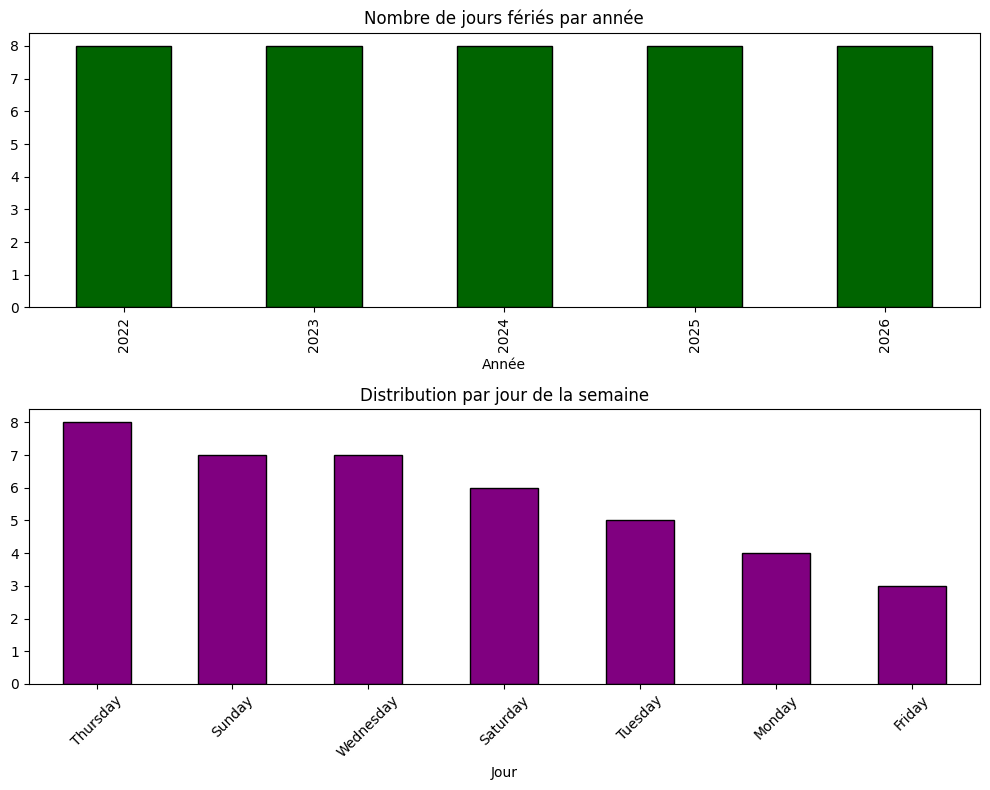

In [12]:
# Analyse exploratoire — Jours fériés (Holidays)
if 'df_holidays' in dir() and df_holidays is not None:
    import matplotlib.pyplot as plt

    # --- Valeurs manquantes ---
    manquantes = df_holidays.isna().sum()
    pct = (manquantes / len(df_holidays) * 100).round(1)
    df_manq = pd.DataFrame({"Valeurs manquantes": manquantes, "%": pct})
    print("Valeurs manquantes par colonne :")
    display(df_manq)
    if manquantes.sum() == 0:
        print("Aucune valeur manquante.")

    # --- Doublons ---
    dup_all = df_holidays.duplicated().sum()
    dup_date_name = df_holidays.duplicated(subset=["date", "name"], keep=False).sum()
    print(f"\nDoublons (lignes entièrement identiques) : {dup_all}")
    print(f"Lignes avec même (date, name) : {dup_date_name}")

    # --- Valeurs aberrantes / cohérence ---
    if "is_holiday" in df_holidays.columns:
        vals = df_holidays["is_holiday"].astype(str).str.strip().unique()
        print(f"\nValeurs uniques is_holiday : {list(vals)}")
    if "is_weekend" in df_holidays.columns:
        vals_w = df_holidays["is_weekend"].astype(str).str.strip().unique()
        print(f"Valeurs uniques is_weekend : {list(vals_w)}")
    if "country_code" in df_holidays.columns:
        print(f"country_code : {df_holidays['country_code'].value_counts().to_dict()}")

    # --- Schémas de distribution ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    # Année déduite de la date (format DD/MM/YYYY)
    try:
        df_holidays["year"] = df_holidays["date"].astype(str).str.split("/").str[-1]
        df_holidays["year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="darkgreen", edgecolor="black")
        axes[0].set_title("Nombre de jours fériés par année")
        axes[0].set_xlabel("Année")
    except Exception as e:
        axes[0].text(0.5, 0.5, f"Erreur date: {e}", ha="center", va="center")
    if "day_of_week" in df_holidays.columns:
        df_holidays["day_of_week"].value_counts().plot(kind="bar", ax=axes[1], color="purple", edgecolor="black")
        axes[1].set_title("Distribution par jour de la semaine")
        axes[1].set_xlabel("Jour")
        axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Charger d'abord df_holidays (cellule section 4.7).")

In [13]:
# Vérification des fichiers scrappés (4 fichiers)
files = ["venues_salles_tunisie_ranim.csv", "tendances_evenementielles_tunisie.csv", "benchmark_prix_marche_tunisie.csv", "external_holidays.csv"]
for f in files:
    p = os.path.join(scratch_dir, f)
    if not os.path.exists(p) and f == "benchmark_prix_marche_tunisie.csv":
        p = os.path.join(scratch_dir, "benchmark_prix_marche_tunisie_latest.csv")
    exists = os.path.exists(p)
    print(f"{f}: {'OK' if exists else 'absent'} -> {p}")

venues_salles_tunisie_ranim.csv: OK -> c:\Users\ranim\Downloads\ValidationPI\ValidationPI\CSV_scrapping\venues_salles_tunisie_ranim.csv
tendances_evenementielles_tunisie.csv: OK -> c:\Users\ranim\Downloads\ValidationPI\ValidationPI\CSV_scrapping\tendances_evenementielles_tunisie.csv
benchmark_prix_marche_tunisie.csv: OK -> c:\Users\ranim\Downloads\ValidationPI\ValidationPI\CSV_scrapping\benchmark_prix_marche_tunisie_latest.csv
external_holidays.csv: OK -> c:\Users\ranim\Downloads\ValidationPI\ValidationPI\CSV_scrapping\external_holidays.csv
